# Computational Track: Circuit Placement, Routing & Scheduling

Welcome to the Bitcamp 2026 quantum computing challenge.

Your task: given a quantum program (a list of two-qubit interactions) and a hardware
connectivity graph, find a **placement** (logical → physical qubit assignment) and a
**routing** (sequence of SWAP insertions) that executes every interaction using the fewest
extra gates and parallel time steps.

This notebook walks you through the problem using live code from the starter kit:

1. **Hardware graph** — what the chip looks like and why its topology matters
2. **Placement** — assigning logical qubits to physical locations before routing
3. **Routing** — inserting SWAP gates to make non-adjacent pairs neighbors
4. **Scheduling** — packing gates into parallel layers to reduce depth
5. **Baseline scores** — what the intentionally bad baseline achieves
6. **Why the baseline is weak** — analysis of the three failure modes
7. **Stretch goals** — gate decomposition and single-qubit optimization
8. **Submission template** — your `solve` function and how to validate it

Read the `README.md` handout alongside this notebook for full problem context and
algorithm references.

In [1]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mplcfg-"))

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "starter_kit").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))
elif (NOTEBOOK_DIR / "Computational Track" / "starter_kit").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR / "Computational Track"))

import matplotlib.pyplot as plt
import networkx as nx
import pennylane as qml
from IPython.display import HTML, display

from starter_kit import (
    BENCHMARKS,
    animate_layers,
    animate_routing,
    baseline_decompose,
    baseline_optimize_1q,
    baseline_solve,
    benchmark_stats,
    build_hardware_graph,
    draw_hardware,
    schedule_layers_ordered,
    score_summary,
)
from starter_kit.baseline_routing import identity_placement

plt.style.use("seaborn-v0_8-whitegrid")
GRAPH = build_hardware_graph()
print(f"Hardware graph: {GRAPH.number_of_nodes()} qubits, {GRAPH.number_of_edges()} connections")
print(f"PennyLane version: {qml.__version__}")

/home/Empty/Bitcamp-2026-Quantum/Computational Track/venv/lib/python3.14/site-packages/autograd/wrap_util.py:38: SyntaxWarning: 'return' in a 'finally' block
  return f


Hardware graph: 20 qubits, 23 connections
PennyLane version: 0.44.1


## 1. The Hardware Graph

The chip is a 20-qubit heavy-hex-style graph. Each **node** is a physical qubit; each
**edge** is a wire that connects two qubits so two-qubit gates can execute between them.

Two-qubit gates can **only** run on adjacent qubit pairs. If a program needs qubits A and B
to interact but they are not neighbors, we must move one of them closer by executing a chain
of SWAP gates — each SWAP costs 1 point in the score.

Key observations:
- **Corner qubits** (0, 3, 16, 19) have degree 1–2 — few connections, expensive to route through.
- **Interior qubits** (5, 9, 10, 13) have degree 3 — more flexible hubs.
- The graph **diameter** is the longest shortest path; it sets a lower bound on the worst-case
  SWAP count for any single interaction.

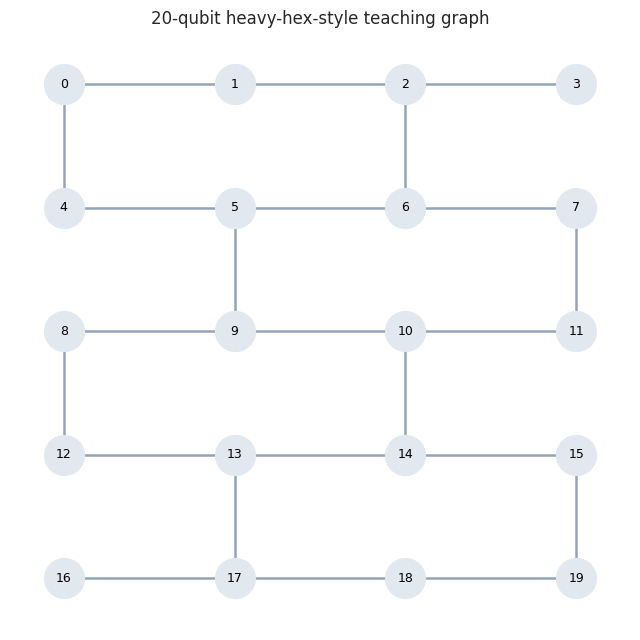

Degree of each physical qubit:
  q 0: degree 2  ##
  q 1: degree 2  ##
  q 2: degree 3  ###
  q 3: degree 1  #
  q 4: degree 2  ##
  q 5: degree 3  ###
  q 6: degree 3  ###
  q 7: degree 2  ##
  q 8: degree 2  ##
  q 9: degree 3  ###
  q10: degree 3  ###
  q11: degree 2  ##
  q12: degree 2  ##
  q13: degree 3  ###
  q14: degree 3  ###
  q15: degree 2  ##
  q16: degree 1  #
  q17: degree 3  ###
  q18: degree 2  ##
  q19: degree 2  ##

Graph diameter: 9
Hardest path example (q0 → q19): [0, 4, 5, 9, 10, 14, 15, 19]  (7 hops)
Any program gate on (q0, q19) requires at least 6 SWAPs.


In [2]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
draw_hardware(GRAPH, ax=ax, title="20-qubit heavy-hex-style teaching graph")
plt.tight_layout()
plt.show()

degrees = dict(GRAPH.degree())
print("Degree of each physical qubit:")
for node in sorted(GRAPH.nodes):
    bar = "#" * degrees[node]
    print(f"  q{node:2d}: degree {degrees[node]}  {bar}")

diameter = nx.diameter(GRAPH)
worst_path = nx.shortest_path(GRAPH, 0, 19)
print(f"\nGraph diameter: {diameter}")
print(f"Hardest path example (q0 → q19): {worst_path}  ({len(worst_path)-1} hops)")
print("Any program gate on (q0, q19) requires at least", len(worst_path)-2, "SWAPs.")

## 2. Programs and the Placement Problem

A **program** is a list of operations in this format:

| Tuple | Meaning |
|---|---|
| `('2Q', i, j)` | Two-qubit gate between logical qubits `i` and `j` |
| `('1Q', i)` | Single-qubit gate on logical qubit `i` |

Our running example is `ghz_star`: logical qubit 0 (the hub) must interact with every other
qubit in sequence — a star topology. This models preparing a GHZ state.

**Placement** maps each logical qubit to a physical qubit before routing begins. The baseline
uses *identity placement*: logical qubit `i` → physical qubit `i`. This ignores the
structure of the program entirely.

In [3]:
program = BENCHMARKS["ghz_star"]
print(f"ghz_star program ({len(program)} operations):")
for op in program:
    print(f"  {op}")

ghz_star program (7 operations):
  ('2Q', 0, 1)
  ('2Q', 0, 2)
  ('2Q', 0, 3)
  ('2Q', 0, 4)
  ('2Q', 0, 5)
  ('2Q', 0, 6)
  ('2Q', 0, 7)


Identity placement (logical → physical qubit):
  L0 → physical  0  (degree 2)  <-- star HUB
  L1 → physical  1  (degree 2)
  L2 → physical  2  (degree 3)
  L3 → physical  3  (degree 1)
  L4 → physical  4  (degree 2)
  L5 → physical  5  (degree 3)
  L6 → physical  6  (degree 3)
  L7 → physical  7  (degree 2)


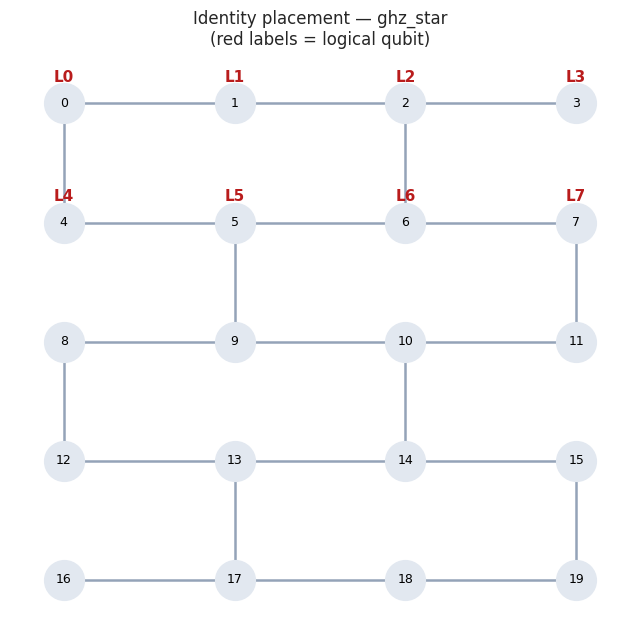


L0 (the star HUB) is on physical 0, which has degree 2.
A star hub should be on a high-degree, central node.  Physical 9 has degree 3 and might be better.


In [4]:
# Identity placement: logical i maps to physical i
placement = identity_placement(program, GRAPH)

print("Identity placement (logical → physical qubit):")
for logical, physical in sorted(placement.items()):
    degree = GRAPH.degree(physical)
    marker = "  <-- star HUB" if logical == 0 else ""
    print(f"  L{logical} → physical {physical:2d}  (degree {degree}){marker}")

# Visualize the placement on the hardware graph
fig, ax = plt.subplots(figsize=(6.5, 6.5))
draw_hardware(GRAPH, placement=placement, ax=ax, title="Identity placement — ghz_star\n(red labels = logical qubit)")
plt.tight_layout()
plt.show()

print()
print(f"L0 (the star HUB) is on physical {placement[0]}, which has degree {GRAPH.degree(placement[0])}.")
print("A star hub should be on a high-degree, central node.  Physical 9 has degree",
      GRAPH.degree(9), "and might be better.")

## 3. Routing — Inserting SWAPs

The baseline router uses a simple greedy strategy: for each gate in program order, if the
two target qubits are not adjacent, it follows the **shortest path** in the hardware graph
and inserts one SWAP per edge along the way, moving one qubit toward the other.

Every SWAP:
1. Exchanges the quantum states of two adjacent qubits.
2. Updates the logical-to-physical mapping accordingly.
3. Adds 1 to the SWAP count (which adds 1 to your score).

Let's route `ghz_star` with the baseline and watch what happens step by step.

In [5]:
placement, routed = baseline_solve(program, GRAPH)

swaps_only = [op for op in routed if op[0] == "SWAP"]
gates_only  = [op for op in routed if op[0] == "2Q"]
print(f"Routed program: {len(swaps_only)} SWAPs + {len(gates_only)} 2Q gates ({len(routed)} ops total)")
print()
print("Full routed sequence:")
for op in routed:
    tag = "  *** SWAP ***" if op[0] == "SWAP" else ""
    print(f"  {op}{tag}")

Routed program: 7 SWAPs + 7 2Q gates (14 ops total)

Full routed sequence:
  ('2Q', 0, 1)
  ('SWAP', 0, 1)  *** SWAP ***
  ('2Q', 1, 2)
  ('SWAP', 1, 2)  *** SWAP ***
  ('2Q', 2, 3)
  ('SWAP', 2, 1)  *** SWAP ***
  ('SWAP', 1, 0)  *** SWAP ***
  ('2Q', 0, 4)
  ('SWAP', 0, 4)  *** SWAP ***
  ('2Q', 4, 5)
  ('SWAP', 4, 5)  *** SWAP ***
  ('2Q', 5, 6)
  ('SWAP', 5, 6)  *** SWAP ***
  ('2Q', 6, 7)


In [6]:
# Animate how qubit positions evolve as SWAPs execute.
# Red highlighted edges = current SWAP or gate being processed.
# Labels above nodes show which logical qubit is currently at that physical location.
anim = animate_routing(placement, routed, GRAPH, interval=750)
display(HTML(anim.to_jshtml()))
plt.close("all")

In [7]:
# Validate correctness and compute the score
summary = score_summary(program, GRAPH, placement, routed)
print(f"Valid:      {summary['valid']}")
print(f"SWAPs:      {summary['swap_count']}")
print(f"Depth:      {summary['depth']}")
print(f"Score:      {summary['score']:.1f}  "
      f"(= {summary['swap_count']} swaps + 0.5 × {summary['depth']} depth)")

Valid:      True
SWAPs:      7
Depth:      14
Score:      14.0  (= 7 swaps + 0.5 × 14 depth)


## 4. Scheduling — Parallel Layers

After routing, the scorer groups operations into **time steps** (layers).  Two 2Q gates can
run in the same layer if and only if:

1. They act on **completely disjoint** qubit sets (no shared qubit), and
2. They respect the **original program order** — a gate cannot jump ahead of earlier
   gates on the same qubits.

`schedule_layers_ordered` assigns each operation to the earliest layer where all its
qubits are free.  Single-qubit gates are considered instantaneous and are excluded
from layer counting.

The score uses `depth = number of layers`, so parallel scheduling directly reduces your
score.  The baseline routing does not try to choose SWAPs that enable more parallelism;
a smarter router can make this much better.

In [8]:
layers = schedule_layers_ordered(routed)
print(f"{len(routed)} operations → {len(layers)} layers (depth {len(layers)})")
print()
for i, layer in enumerate(layers, 1):
    print(f"  Layer {i:2d}: {layer}")

14 operations → 14 layers (depth 14)

  Layer  1: [('2Q', 0, 1)]
  Layer  2: [('SWAP', 0, 1)]
  Layer  3: [('2Q', 1, 2)]
  Layer  4: [('SWAP', 1, 2)]
  Layer  5: [('2Q', 2, 3)]
  Layer  6: [('SWAP', 2, 1)]
  Layer  7: [('SWAP', 1, 0)]
  Layer  8: [('2Q', 0, 4)]
  Layer  9: [('SWAP', 0, 4)]
  Layer 10: [('2Q', 4, 5)]
  Layer 11: [('SWAP', 4, 5)]
  Layer 12: [('2Q', 5, 6)]
  Layer 13: [('SWAP', 5, 6)]
  Layer 14: [('2Q', 6, 7)]


In [9]:
layer_anim = animate_layers(layers, interval=900)
display(HTML(layer_anim.to_jshtml()))
plt.close("all")

## 5. Baseline Scores on All Benchmarks

The six starter benchmarks span a range of sizes and topologies.  Let's run the baseline
on all of them and look at where the cost is coming from.

Scoring formula (lower is better):
```
score = swap_count + 0.5 × depth
```

A solution is **invalid** (score = ∞) if any gate touches non-adjacent physical qubits, or
if stripping the SWAPs leaves a program different from the original.

In [10]:
print(f"{'benchmark':15s}  {'lq':>2s}  {'2Q':>3s}  {'valid':5s}  {'swaps':>5s}  {'depth':>5s}  {'score':>7s}")
print("─" * 58)
for name, prog in BENCHMARKS.items():
    stats = benchmark_stats(prog)
    pl, rt = baseline_solve(prog, GRAPH)
    s = score_summary(prog, GRAPH, pl, rt)
    ok = "OK" if s["valid"] else "FAIL"
    print(f"{name:15s}  {stats['logical_qubits']:2d}  {stats['two_qubit_ops']:3d}  "
          f"{ok:5s}  {s['swap_count']:5d}  {s['depth']:5d}  {s['score']:7.1f}")

benchmark        lq   2Q  valid  swaps  depth    score
──────────────────────────────────────────────────────────
ghz_star          8    7  OK         7     14     14.0
chain_trotter    10    9  OK         7     16     15.0
ladder_trotter   12   16  OK        25     21     35.5
qaoa_random      10   18  OK        26     26     39.0
dense_random     14   40  OK        90     64    122.0
vqe_layers       16   45  OK        42     32     58.0


## 6. Why Is the Baseline Weak?

Three compounding problems make the baseline easy to beat.

### Problem 1 — Identity Placement Ignores Program Structure

In `ghz_star`, L0 interacts with every other qubit — it is the star hub and should be on
a **central**, **high-degree** physical qubit so all leaves are nearby.  Identity placement
dumps L0 on physical qubit 0, a degree-2 corner.

Let's measure the total distance from the hub to each leaf under identity placement, then
compare with a few alternative hub locations.

In [11]:
placement, _ = baseline_solve(program, GRAPH)
hub_phys = placement[0]
leaf_physicals = {log: placement[log] for log in range(1, 8)}

print(f"Identity placement: L0 (star hub) → physical {hub_phys}  (degree {GRAPH.degree(hub_phys)})")
print()
print("Distance from hub to each leaf:")
total_identity = 0
for logical, phys in sorted(leaf_physicals.items()):
    d = nx.shortest_path_length(GRAPH, hub_phys, phys)
    total_identity += d
    note = "" if d > 1 else "  (adjacent — 0 SWAPs!)"
    print(f"  L{logical} → physical {phys:2d}: {d} hops{note}")
print(f"Total distance from hub to all leaves: {total_identity}")

print()
print("Comparison — if we move just the hub to a different physical qubit")
print("(leaves stay at physicals 1–7):")
for candidate in [5, 9, 10, 13]:
    total = sum(nx.shortest_path_length(GRAPH, candidate, p) for p in leaf_physicals.values())
    print(f"  Hub on physical {candidate:2d} (degree {GRAPH.degree(candidate)}): total distance = {total}")
print(f"  Hub on physical {hub_phys:2d} (identity, degree {GRAPH.degree(hub_phys)}):  total distance = {total_identity}  <-- baseline")

Identity placement: L0 (star hub) → physical 0  (degree 2)

Distance from hub to each leaf:
  L1 → physical  1: 1 hops  (adjacent — 0 SWAPs!)
  L2 → physical  2: 2 hops
  L3 → physical  3: 3 hops
  L4 → physical  4: 1 hops  (adjacent — 0 SWAPs!)
  L5 → physical  5: 2 hops
  L6 → physical  6: 3 hops
  L7 → physical  7: 4 hops
Total distance from hub to all leaves: 16

Comparison — if we move just the hub to a different physical qubit
(leaves stay at physicals 1–7):
  Hub on physical  5 (degree 3): total distance = 12
  Hub on physical  9 (degree 3): total distance = 19
  Hub on physical 10 (degree 3): total distance = 24
  Hub on physical 13 (degree 3): total distance = 38
  Hub on physical  0 (identity, degree 2):  total distance = 16  <-- baseline


### Problem 2 — Greedy Routing With No Look-Ahead

The baseline routes each gate independently using the shortest path **at the moment that
gate is processed**.  It doesn't consider whether a SWAP that helps gate N will leave some
qubit stranded far from where gate N+1 needs it.

### Problem 3 — No SWAP Candidate Scoring

When multiple SWAPs could progress the current gate, the baseline just picks the first
edge on the shortest path.  A smarter router evaluates several SWAP candidates and
chooses the one that most reduces expected future cost across the next K gates
(the *look-ahead window* in the SABRE algorithm).

**The SABRE algorithm** (IBM tutorial linked in the README) addresses all three problems.
Starting from this baseline and reading SABRE side-by-side is a good way to understand
exactly why each design decision exists.

## 7. Stretch Goals — Gate Decomposition and 1Q Optimization

Real hardware only executes a limited **native gate set**: `{RZ, SX, CNOT}`.
Every abstract gate (SWAP, Hadamard, Toffoli, …) must be **decomposed** into this set.

**Stretch Goal A** asks you to implement a `decompose(routed_program)` function that
converts the routed circuit into native gates.

**Stretch Goal B** asks you to implement `optimize_1q(decomposed)` that simplifies
consecutive single-qubit gates (merging rotations, cancelling inverse pairs, etc.).

The baseline decomposer (`baseline_decompose`) is intentionally wasteful: it inserts
`RZ(0.0)` identity rotations everywhere.  The baseline 1Q optimizer does nothing at all.

In [12]:
from starter_kit.baseline_decompose import decompose as baseline_decompose
from starter_kit.baseline_oneq import optimize_1q as baseline_optimize_1q

# A small routed circuit to decompose: one SWAP, one 1Q gate, one 2Q gate
tiny_routed = [("SWAP", 2, 6), ("1Q", 0), ("2Q", 6, 7)]

decomposed = baseline_decompose(tiny_routed)
optimized  = baseline_optimize_1q(decomposed)

print(f"Routed circuit ({len(tiny_routed)} abstract ops):")
for op in tiny_routed:
    print(f"  {op}")

print(f"\nBaseline decomposition ({len(decomposed)} native gates):")
for op in decomposed:
    note = "  # identity!" if op[0] == "RZ" and op[2] == 0.0 else ""
    print(f"  {op}{note}")

n_identity = sum(1 for op in decomposed if op[0] == "RZ" and op[2] == 0.0)
print(f"\nIdentity RZ(0) gates: {n_identity} / {len(decomposed)} "
      f"({100 * n_identity / len(decomposed):.0f}% wasted gates)")
print(f"1Q optimizer changed anything: {optimized != decomposed}  (baseline does nothing)")

Routed circuit (3 abstract ops):
  ('SWAP', 2, 6)
  ('1Q', 0)
  ('2Q', 6, 7)

Baseline decomposition (13 native gates):
  ('RZ', 2, 0.0)  # identity!
  ('CNOT', 2, 6)
  ('RZ', 6, 0.0)  # identity!
  ('CNOT', 6, 2)
  ('RZ', 2, 0.0)  # identity!
  ('CNOT', 2, 6)
  ('RZ', 6, 0.0)  # identity!
  ('RZ', 0, 0.0)  # identity!
  ('SX', 0)
  ('RZ', 0, 0.0)  # identity!
  ('RZ', 6, 0.0)  # identity!
  ('CNOT', 6, 7)
  ('RZ', 7, 0.0)  # identity!

Identity RZ(0) gates: 8 / 13 (62% wasted gates)
1Q optimizer changed anything: False  (baseline does nothing)


In [13]:
# PennyLane's built-in single_qubit_fusion transform can immediately eliminate the waste.
# This is the direction Stretch Goal B points you toward.
with qml.queuing.AnnotatedQueue() as queue:
    # Simulate what the baseline produces for one 1Q gate: RZ(0) + SX + RZ(0) + RZ(0) padding
    qml.RZ(0.0, wires=0)
    qml.SX(wires=0)
    qml.RZ(0.0, wires=0)
    qml.RZ(0.0, wires=0)

script = qml.tape.QuantumScript.from_queue(queue)
fused_batch, _ = qml.transforms.single_qubit_fusion(script)
fused = fused_batch[0]

original_names = [f"{op.name}({[round(float(p), 3) for p in op.parameters]})" for op in script.operations]
fused_names    = [f"{op.name}({[round(float(p), 3) for p in op.parameters]})" for op in fused.operations]

print("Before fusion:", original_names)
print("After fusion: ", fused_names)
print(f"Gates: {len(script.operations)} → {len(fused.operations)}")
print()
print("For Stretch Goal A, use known minimal decompositions instead of the baseline padding.")
print("For Stretch Goal B, apply PennyLane transforms (merge_rotations, cancel_inverses,")
print("or single_qubit_fusion) to the decomposed output.")

Before fusion: ['RZ([0.0])', 'SX([])', 'RZ([0.0])', 'RZ([0.0])']
After fusion:  ['Rot([1.571, 1.571, -1.571])', 'GlobalPhase([-0.785])']
Gates: 4 → 2

For Stretch Goal A, use known minimal decompositions instead of the baseline padding.
For Stretch Goal B, apply PennyLane transforms (merge_rotations, cancel_inverses,
or single_qubit_fusion) to the decomposed output.


## 8. Your Submission

Implement the `solve` function below.  The expected interface:

```python
def solve(program, hardware_graph):
    # Returns:
    #   initial_placement : dict[int, int]  — logical qubit → physical qubit
    #   routed_program    : list[tuple]     — ops on physical qubits, SWAPs inserted
```

Every `('2Q', p, q)` in your routed program **must** satisfy `hardware_graph.has_edge(p, q)`.
Stripping your SWAPs must recover the original program in order.

Use `score_summary` to validate correctness and measure your score against the baseline.

**Suggested first steps (easiest to hardest)**:

1. Replace identity placement with degree-matching: sort logical qubits by how many
   interactions they have, and assign them to physical qubits sorted by degree.
2. Try `N` random placements and keep the lowest-scoring one (fast, surprisingly effective).
3. Score multiple SWAP candidates for each gate instead of taking the first shortest-path SWAP.
4. Add a look-ahead window: pick the SWAP that most reduces total distance across the next
   K pending gates (K=5 is a good start).
5. Implement SABRE-style bidirectional routing (see the IBM tutorial in the README).

In [14]:
def solve(program, hardware_graph):
    """
    Replace this with your own placement + routing strategy.

    Args:
        program        : list of ('2Q', i, j) and ('1Q', i) tuples on logical qubits
        hardware_graph : networkx.Graph — the hardware connectivity

    Returns:
        initial_placement : dict mapping logical qubit index → physical qubit index
        routed_program    : list of tuples on physical qubits, with ('SWAP', p, q) inserted
                           Every ('2Q', p, q) must satisfy hardware_graph.has_edge(p, q).
    """
    raise NotImplementedError("Implement your solver here.")


# ── Test your solver ──────────────────────────────────────────────────────────
test_name = "ghz_star"
test_program = BENCHMARKS[test_name]

# Baseline for comparison
bl_pl, bl_rt = baseline_solve(test_program, GRAPH)
bl_result = score_summary(test_program, GRAPH, bl_pl, bl_rt)
print(f"Baseline score on {test_name}: {bl_result['score']:.1f}  "
      f"({bl_result['swap_count']} swaps, depth {bl_result['depth']})")
print()

try:
    my_placement, my_routed = solve(test_program, GRAPH)
    result = score_summary(test_program, GRAPH, my_placement, my_routed)

    print(f"Your result on {test_name}:")
    print(f"  Valid:  {result['valid']}")
    if not result["valid"]:
        print(f"  Error:  {result['message']}")
    else:
        print(f"  SWAPs:  {result['swap_count']}")
        print(f"  Depth:  {result['depth']}")
        print(f"  Score:  {result['score']:.1f}")
        delta = result["score"] - bl_result["score"]
        if delta < 0:
            print(f"  ✓ You beat the baseline by {-delta:.1f} points!")
        elif delta == 0:
            print("  Tied with the baseline.")
        else:
            print(f"  Still {delta:.1f} points behind the baseline.")
except NotImplementedError:
    print("Implement solve() above, then re-run this cell.")

Baseline score on ghz_star: 14.0  (7 swaps, depth 14)

Implement solve() above, then re-run this cell.
